In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



It allows the notebook to access datasets stored in Drive, such as training and testing images.

//content/drive becomes the root directory for Drive files

Required when datasets are too large to upload manually

In [4]:
train_path = "/content/drive/MyDrive/train"
test_path = "/content/drive/MyDrive/test"


In [5]:
import os

classes = os.listdir(train_path)
print("Available classes:", classes)

Available classes: ['tomato', 'indian market', 'potato', 'onion']


reads all subfolder names inside the training directory.

Each subfolder represents one class label.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob


In [7]:
base_dir = train_path
all_image_paths = glob(os.path.join(base_dir, "*", "*"))
print("Total images found:", len(all_image_paths))


Total images found: 2297



First * → class folders

Second * → image files inside each class

Purpose:

Verify dataset loading

Understand dataset size before training

In [8]:
# Count images per class
classes = os.listdir(base_dir)
image_count = {
    cls: len(os.listdir(os.path.join(base_dir, cls)))
    for cls in os.listdir(base_dir)
}
print(image_count)


{'tomato': 35, 'indian market': 554, 'potato': 898, 'onion': 810}




Iterates through each class folder

Counts images inside each folder

Stores results in a dictionary

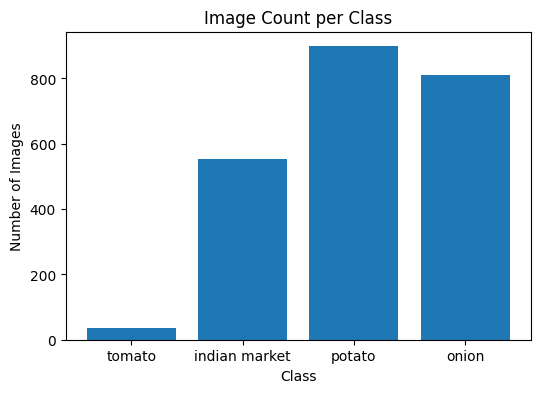

In [9]:
#viz
plt.figure(figsize=(6,4))
plt.bar(image_count.keys(), image_count.values())
plt.title("Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


X-axis → Class names (tomato, onion, potato, indian market)

Y-axis → Number of images in each class

plt.bar() → creates a bar graph for easy comparison

 **Purpose of this visualization**

Understand dataset balance

Identify class imbalance issues

Decide whether data augmentation is required

**Insight:**
Some classes contain more images than others, which may affect model performance if not handled properly.

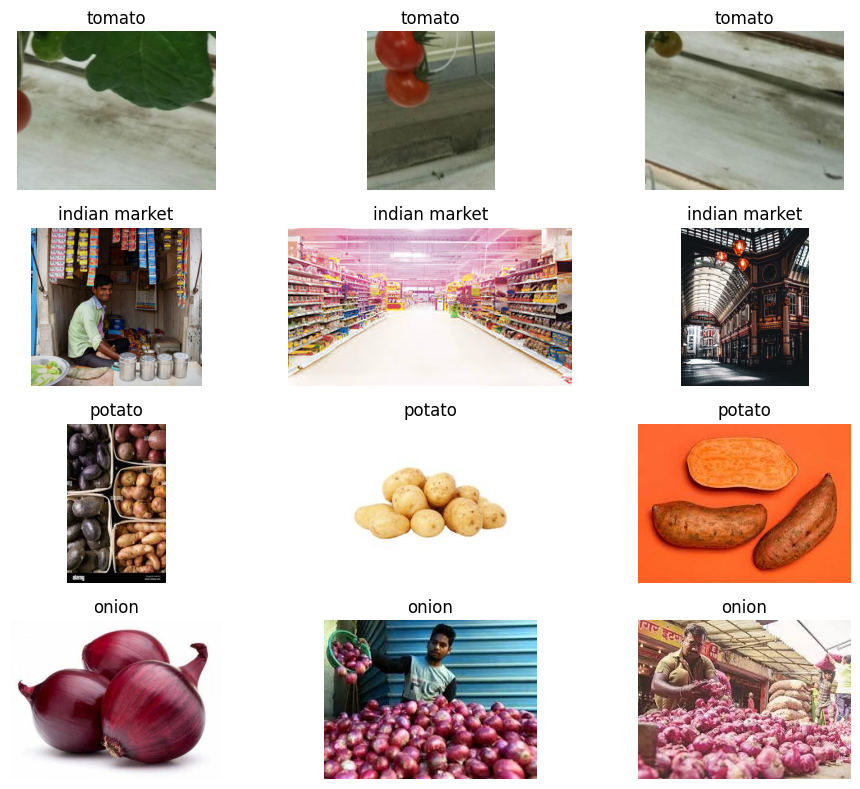

In [10]:
#Visualisation
import random
plt.figure(figsize=(10,8))
for i, cls in enumerate(classes):
    img_paths = glob(os.path.join(base_dir, cls, "*"))
    for j in range(3):
        img = plt.imread(random.choice(img_paths))
        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(cls)
plt.tight_layout()
plt.show()


sample images from each class to visually inspect the dataset.

**It works**

Iterates through each class folder

Randomly selects 3 images per class

Displays images in a grid format using subplots

**importants:**

Confirms images are loaded correctly

Helps identify noisy or incorrect images

Ensures visual difference between classes

Improves understanding of real-world data

**Visualization Layout**

Rows → Different classes

Columns → Random samples per class

**Data Preprocessing**

In [11]:
import tensorflow as tf

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

defines key preprocessing parameters:

IMG_SIZE (224 × 224)
All images are resized to this size to maintain uniform input shape
This size is commonly used for CNN and transfer learning models

BATCH_SIZE = 32
Number of images processed together in one training step
Helps in faster and stable training

In [13]:
train_dir = train_path

dataset path to a variable that will be used to load images from Google Drive.

In [14]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = 'int',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 2297 files belonging to 4 classes.
Using 1838 files for training.


label_mode='int' → class labels are integers (0, 1, 2, …)

image_size=IMG_SIZE → resizes images to 224×224

batch_size=BATCH_SIZE → loads images in batches of 32

shuffle=True → randomizes image order

validation_split=0.2 → reserves 20% data for validation

subset="training" → loads only training data

seed=42 → ensures reproducibility

**Output**

Total images found: 2297

Images used for training: 1838

In [15]:
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = 'int',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 2297 files belonging to 4 classes.
Using 459 files for validation.


Validation data is used to:

Evaluate model performance

Prevent overfitting

Tune model parameters

 **Output**

Validation images: 459

In [16]:
train_ds = train_ds_raw.map(lambda x, y: (x/255.0, y))
val_ds = val_ds_raw.map(lambda x, y: (x/255.0, y))

Normalizes image pixel values from 0–255 to 0–1.

 **normalization importance**

Improves model convergence

Makes training faster and more stable

Standard practice in deep learning

**Model Buiding**

In [17]:

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

Keras modules for building and managing the model:

layers → used to create CNN layers (Conv2D, MaxPooling, Dense, etc.)

models → used to define the Sequential model

EarlyStopping → stops training when validation performance stops improving

plot_model → used to visualize the model architecture

In [18]:
model = models.Sequential([

    #CNN-1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224,3)),
    layers.MaxPooling2D((2, 2)),

     #CNN-2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

      #CNN-3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#CNN-1
Conv2D layer

32 filters

Kernel size: 3×3

ReLU activation for non-linearity

Input shape: 224×224 RGB image

MaxPooling2D

Pool size: 2×2

Reduces image size and computation

Helps extract dominant features

#CNN-2

Increases filters from 32 → 64

Learns more complex patterns

Further reduces spatial dimensions

#CNN-3
Uses 128 filters for high-level feature extraction

Helps model understand object shapes and patterns

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**It shows:**

Layer names and types

Output shape of each layer

Number of parameters per layer

Total trainable parameters

**Key Insight**

Total parameters: ~11.17 million

Most parameters are in the Dense (Fully Connected) layer, which learns high-level patterns.

No non-trainable parameters are present.

This confirms the model architecture is correctly built and ready for training.

In [20]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

prepares the model for training.

**Optimizer** (adam)
Adam is an efficient optimization algorithm that adjusts the learning rate automatically.

**Loss function** (sparse_categorical_crossentropy)
Used for multi-class classification when labels are integers.

**Metric** (accuracy)
Measures how many predictions are correct.

In [21]:
early_stop = EarlyStopping(monitor="val_accuracy",patience=3,restore_best_weights=True)

Early Stopping to avoid overfitting.

Monitors validation accuracy

Stops training if no improvement for 3 epochs

Restores the best-performing weights

In [22]:
history = model.fit(train_ds,validation_data=val_ds,epochs=5,callbacks=[early_stop],verbose=1)

Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 296s 5s/step - accuracy: 0.3871 - loss: 2.0461 - val_accuracy: 0.7081 - val_loss: 0.7286
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.6827 - loss: 0.7708 - val_accuracy: 0.7647 - val_loss: 0.6553
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.7398 - loss: 0.6354 - val_accuracy: 0.7996 - val_loss: 0.5371
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.7840 - loss: 0.5468 - val_accuracy: 0.7996 - val_loss: 0.5039
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.7959 - loss: 0.4773 - val_accuracy: 0.8039 - val_loss: 0.5178


Trains the CNN model.

train_ds → training dataset

val_ds → validation dataset

epochs = 5 → model trains for 5 cycles

callbacks → applies EarlyStopping

verbose = 1 → displays training progress

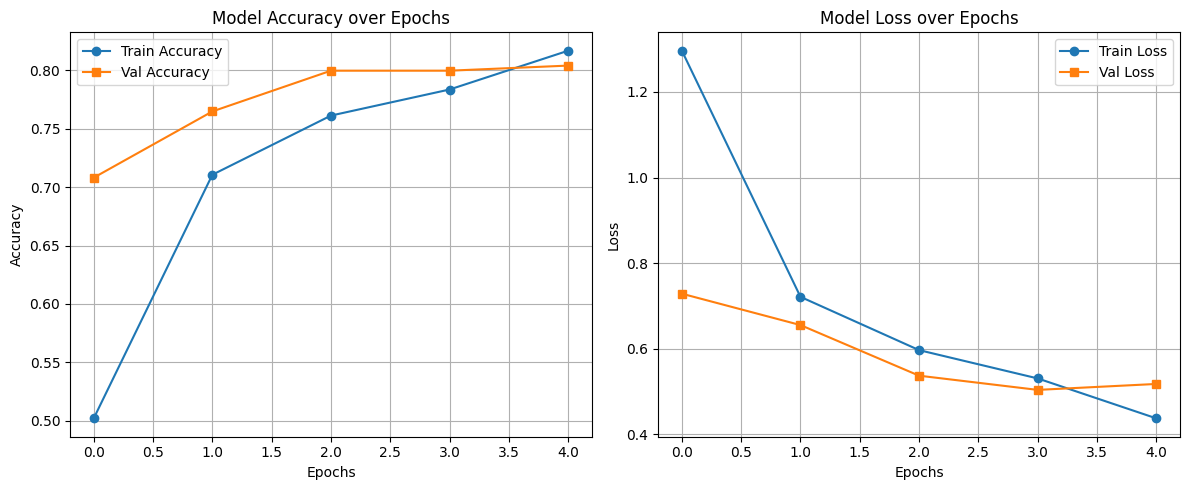

In [23]:
# ==============================================
#  Plot Accuracy and Loss Curves
# ==============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# ----- Accuracy Plot -----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ----- Loss Plot -----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


This plot shows training and validation accuracy across epochs.

**Purpose:**

Check learning progress

Compare training vs validation performance

Detect overfitting or underfitting

This plot shows training and validation loss over epochs.

**Purpose:**

Ensure loss is decreasing

Verify stable training

Confirm model convergence

**PURPOSE**

Adjusts spacing and displays the accuracy and loss plots clearly.

**Model Evaluation on the test dataset**

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [25]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size = (224,224),
    batch_size = 6,
    shuffle = True
)

Found 244 files belonging to 4 classes.


Loads the test dataset from the specified directory.

image_size=(224,224) → resizes test images to match training size

batch_size=6 → loads 6 images at a time for visualization

shuffle=True → randomizes images for unbiased evaluation

**Output**

Total test images found: 244

Number of classes: 4

In [26]:
class_names = test_ds.class_names
class_names



['indian market', 'onion', 'potato', 'tomato']

Retrieves the class labels detected from the test dataset folder structure.

In [27]:
# Take one batch
images, labels = next(iter(test_ds))

Extracts one batch of images and their true labels from the test dataset.

images → image tensors

labels → actual class labels

Used for prediction and visualization.

In [28]:
# Predict
preds = model.predict(images / 255.0)
pred_labels = np.argmax(preds, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step


Prediction using the trained CNN model.

Images are normalized by dividing by 255

model.predict() returns class probabilities

argmax() selects the class with highest probability

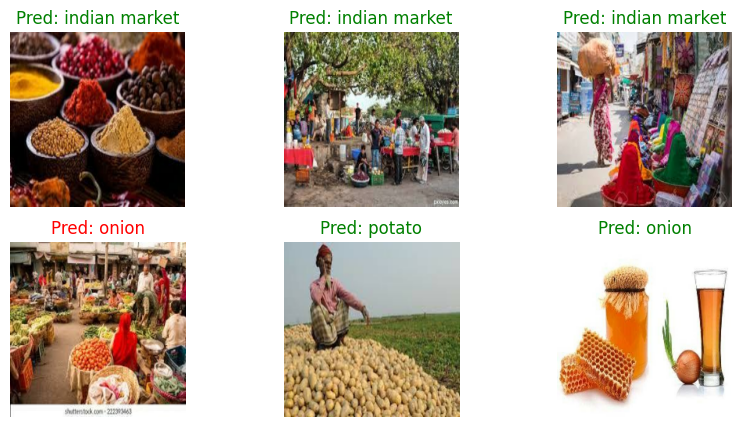

In [29]:
# Plot results
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    color = "green" if pred_labels[i] == labels[i] else "red"
    plt.title(f"Pred: {class_names[pred_labels[i]]}", color=color)
    plt.axis("off")

plt.show()

***CONCLUSION :-***

In this project, a Convolutional Neural Network (CNN) was developed to classify
images into four categories: indian market, onion, potato, and tomato.
The model was trained and validated successfully and achieved good accuracy.
Testing on unseen images showed correct predictions, proving the effectiveness
of the model.
